In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

# loading the dataset 

In [8]:

df= pd.read_csv('Downloads/wine+quality/winequality-white.csv' ,  sep=';') # white wine data 



In [10]:
df.head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
7,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
8,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6


# understanfing the dataset 

In [11]:
df.shape 
# 48988 rows and 12 columns 

(4898, 12)

In [12]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [16]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


# data cleaning 

In [17]:
df.isnull()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,False,False,False,False,False,False,False,False,False,False,False,False
4894,False,False,False,False,False,False,False,False,False,False,False,False
4895,False,False,False,False,False,False,False,False,False,False,False,False
4896,False,False,False,False,False,False,False,False,False,False,False,False


In [18]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.duplicated()

0       False
1       False
2       False
3       False
4        True
        ...  
4893    False
4894    False
4895    False
4896    False
4897    False
Length: 4898, dtype: bool

In [21]:
df.duplicated().sum()

np.int64(937)

In [23]:
df['chlorides'].duplicated()

0       False
1       False
2       False
3       False
4        True
        ...  
4893     True
4894     True
4895     True
4896     True
4897     True
Name: chlorides, Length: 4898, dtype: bool

In [28]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [30]:
df=df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.shape

(3961, 12)

In [34]:
 df.dtypes
# all are numerical features 

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

# EDA

# checking for unusual outliers 

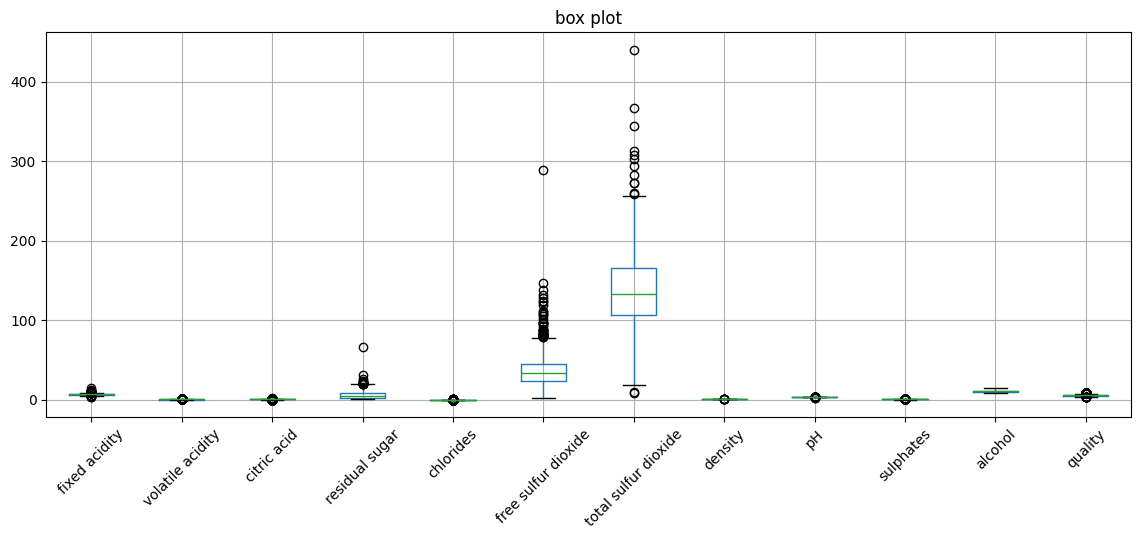

In [35]:
df.select_dtypes(include=np.number).boxplot(figsize=(14,5), rot=45) 
plt.title("box plot") 
plt.show()

# The box plot shows that free sulfur dioxide and total sulfur dioxide contain several statistically identified outliers. These observations represent wines with unusually high sulfur dioxide concentrations. Since sulfur dioxide is a legitimate chemical component used in winemaking, these observations cannot be assumed to be erroneous and are therefore retained. Their potential influence on wine quality will be evaluated through correlation analysis, visualization, and model diagnostics

# Understanding relation between features variables 

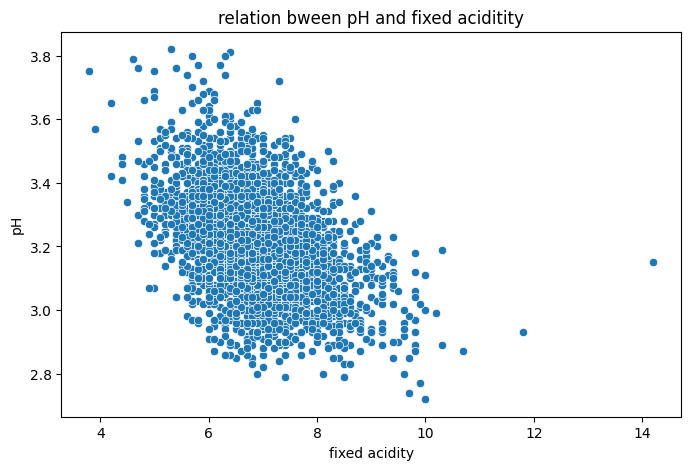

In [36]:
plt.figure(figsize=(8,5) ) 
sns.scatterplot(data = df , x='fixed acidity' , y= 'pH')
plt.title("relation bween pH and fixed aciditity") 
plt.xlabel('fixed acidity') 
plt.ylabel('pH') 
plt.show()

In [37]:
df[['fixed acidity' , 'pH']].corr()

,fixed acidity,pH
fixed acidity,1.000000,-0.431274
pH,-0.431274,1.000000


#The scatter plot indicates a negative relationship between fixed acidity and pH. As fixed acidity increases, pH generally decreases. However, the considerable spread of observations suggests that fixed acidity alone does not completely explain the variation in pH.

# volatile acidity vs quality 
#I expect volatile acidity to have a negative relationship with wine quality because higher volatile acidity can negatively affect the taste and aroma of wine.

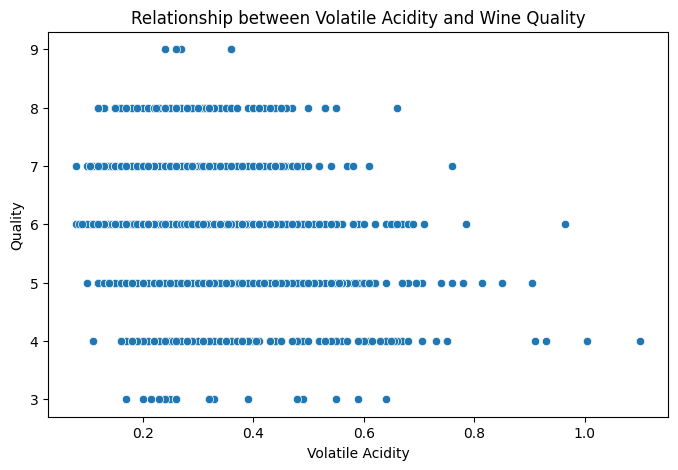

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df , x='volatile acidity' , y='quality')
plt.title('Relationship between Volatile Acidity and Wine Quality')
plt.xlabel('Volatile Acidity')
plt.ylabel('Quality')
plt.show()

In [39]:
df[['volatile acidity' , 'quality']].corr()

,volatile acidity,quality
volatile acidity,1.000000,-0.190678
quality,-0.190678,1.000000


#the correlation bween volatile acidity and quality is -0.190 , indicating a weak negative linear relationship . this suggests that as volatile acidity changes wine quality tends to decrease 

# alcohol vs quality |

#I expect alcohol to have a positive relationship with wine quality because alcohol content can influence the body, taste, and overall characteristics of wine. 

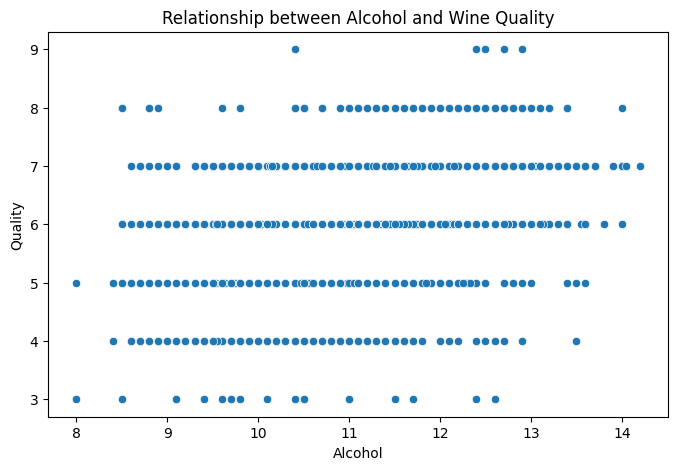

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Relationship between Alcohol and Wine Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

In [41]:
df[['alcohol' , 'quality']].corr()

,alcohol,quality
alcohol,1.000000,0.462869
quality,0.462869,1.000000


#the corr bween alcohol and quality is +0.462 , indicating a moderate positive linear realtionship , this suggests that as alcohol content increases , wine quality tends to increase 

# sulphates vs quality 

#I expect sulphates to have some relationship with wine quality because sulphates are involved in wine preservation and can influence wine characteristics.

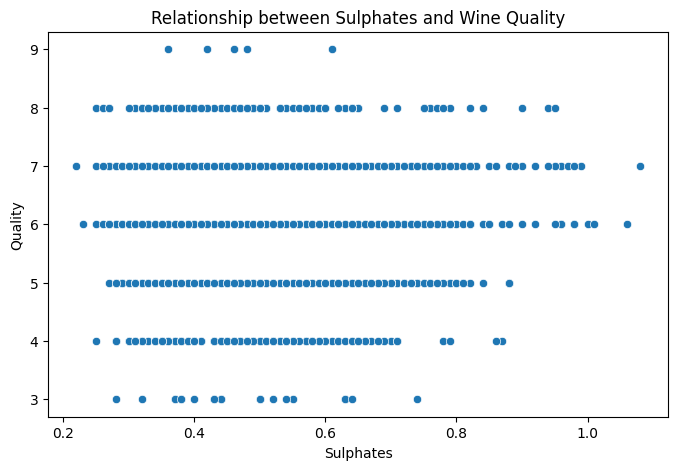

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sulphates', y='quality')
plt.title('Relationship between Sulphates and Wine Quality')
plt.xlabel('Sulphates')
plt.ylabel('Quality')
plt.show()

In [43]:
df[['sulphates' , 'quality']].corr()


,sulphates,quality
sulphates,1.0000,0.0532
quality,0.0532,1.0000


#THE corr bween sulphates and quality is 0.0532 indicating a weak +ve linear relationship . this suggests that sulphate concentration has a weak linear association with wine quality 

# correlation matrix 

In [48]:
numeric_df = df.select_dtypes(include=np.number) 
numeric_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


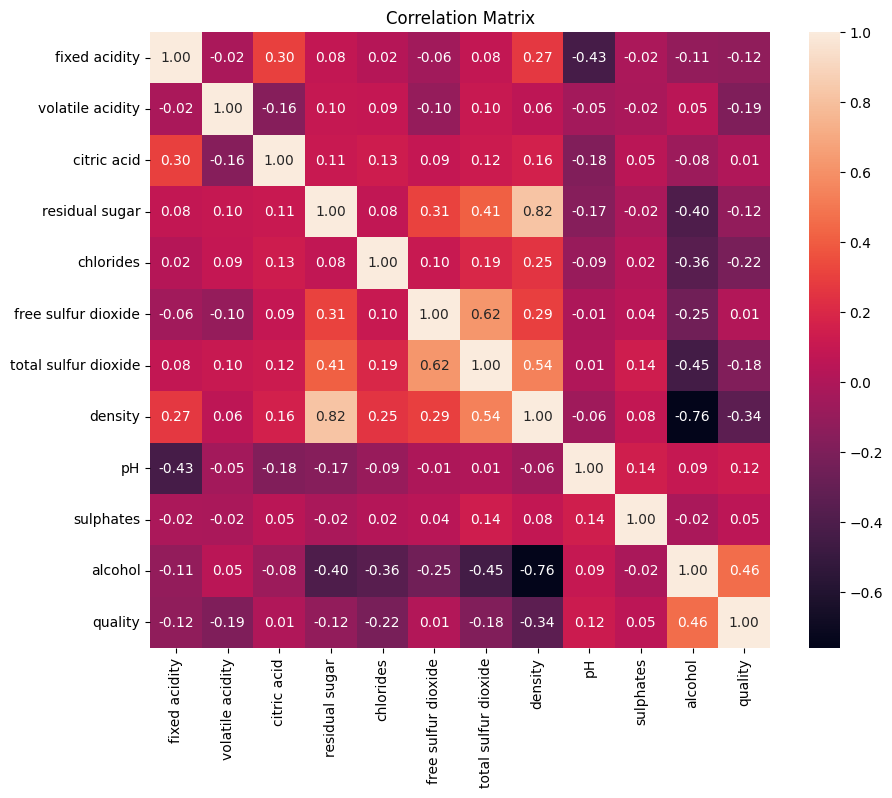

In [57]:
correlation_matrix = numeric_df.corr() 
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix , annot=True , fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


#Alcohol, residual sugar, and density have strong relationships with each other, while alcohol has the strongest positive linear relationship with wine quality among the individual features.

# defining x and y 

In [61]:
x = df.drop('quality' , axis=1)
y = df['quality']


# train test split 

In [69]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.20 , random_state=42)

In [70]:
print("x shape:", x.shape)
print("y shape:" , y.shape)
print('\nx columns :')
print(x.columns.to_list()) 
print("\ntarget y")
print(y.head())
print(y.dtype)

x shape: (3961, 11)
y shape: (3961,)

x columns :
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

target y
0    6
1    6
2    6
3    6
6    6
Name: quality, dtype: int64
int64


# identifying numeric and categorical features

In [96]:
numeric_features = x.select_dtypes(include=['int64','float64']).columns

print(numeric_features) 
print(list(numeric_features))

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# preprocessing

In [97]:
numeric_transformer= Pipeline(steps=[("imputer", SimpleImputer(strategy='median')) , ("scaler", StandardScaler())])

In [98]:
preprocessor = ColumnTransformer(transformers=[('numeric',numeric_transformer, numeric_features)])

In [99]:
print(numeric_features) 
print(type(numeric_features))

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')
<class 'pandas.Index'>


# linear regression model 

In [125]:
model = Pipeline(steps=[('preprocessor' , preprocessor),('regressor' , LinearRegression())])
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

# make predictions 

In [101]:
y_pred = model.predict(x_test)

# cost functions 

# mse

In [104]:
mse = mean_squared_error(y_test , y_pred)
print('mean squared error :', mse)

mean squared error : 0.607131956545196


In [105]:
rmse = np.sqrt(mse)
print('root mean squared error :',rmse)

root mean squared error : 0.7791867276495384


#The model's predictions are typically around 0.78 quality points away from the actual wine quality.

In [106]:
mae = mean_absolute_error(y_test , y_pred)
print("mean absolute error:", mae)

mean absolute error: 0.5973645217257016


#on average predictions are 0.597 score points away from the actual value 

# computing the cost evaluation function 

In [108]:
print("model evaluation")
print('___')
print(f"mse:{mse:4f}") 
print(f"rmse:{rmse:4f}") 
print(f"mae:{mae:4f}") 


model evaluation
___
mse:0.607132
rmse:0.779187
mae:0.597365


# r2 score 

In [109]:
r2 = r2_score(y_test , y_pred) 
print(r2)

0.2597097667382343


In [110]:
y_train_pred = model.predict(x_train)

train_r2 = r2_score(y_train, y_train_pred)

print("Train R²:", train_r2)
print("Test R²:", r2)

Train R²: 0.3083196276550564
Test R²: 0.2597097667382343


# model is not showing overfitting problems 

# The linear regression model achieved an R² score of 0.2597, indicating that approximately 25.97% of the variation in wine quality is explained by the chemical features included in the model. The relatively low R² suggests that a simple linear model does not capture a large proportion of the factors contributing to wine quality

# The relatively close training and test R² values indicate that the model generalizes reasonably consistently, but its explanatory power is limited. This suggests that wine quality is not well explained by simple linear relationships among the available chemical features.

# coefficients 

In [111]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out() 

In [112]:
coefficients = model.named_steps['regressor'].coef_

In [113]:
coef_df = pd.DataFrame({'features':feature_names, 'coefficients':coefficients})
coef_df

,features,coefficients
0,numeric__fixed acidity,0.022253
1,numeric__volatile acidity,-0.175230
2,numeric__citric acid,0.032698
3,numeric__residual sugar,0.283919
4,numeric__chlorides,-0.014738
5,numeric__free sulfur dioxide,0.109253
6,numeric__total sulfur dioxide,-0.032665
7,numeric__density,-0.315669
8,numeric__pH,0.101772
9,numeric__sulphates,0.067770


In [119]:
# sort the values 
coef_df["absolute coefficients"] = (coef_df['coefficients'].abs())
coef_df = coef_df.sort_values(by='absolute coefficients',ascending=False) 
coef_df.head(15)

,features,coefficients,absolute coefficients
7,numeric__density,-0.315669,0.315669
10,numeric__alcohol,0.300236,0.300236
3,numeric__residual sugar,0.283919,0.283919
1,numeric__volatile acidity,-0.175230,0.175230
5,numeric__free sulfur dioxide,0.109253,0.109253
8,numeric__pH,0.101772,0.101772
9,numeric__sulphates,0.067770,0.067770
2,numeric__citric acid,0.032698,0.032698
6,numeric__total sulfur dioxide,-0.032665,0.032665
0,numeric__fixed acidity,0.022253,0.022253


# which feature have stronger infuluence on target variable (quality )

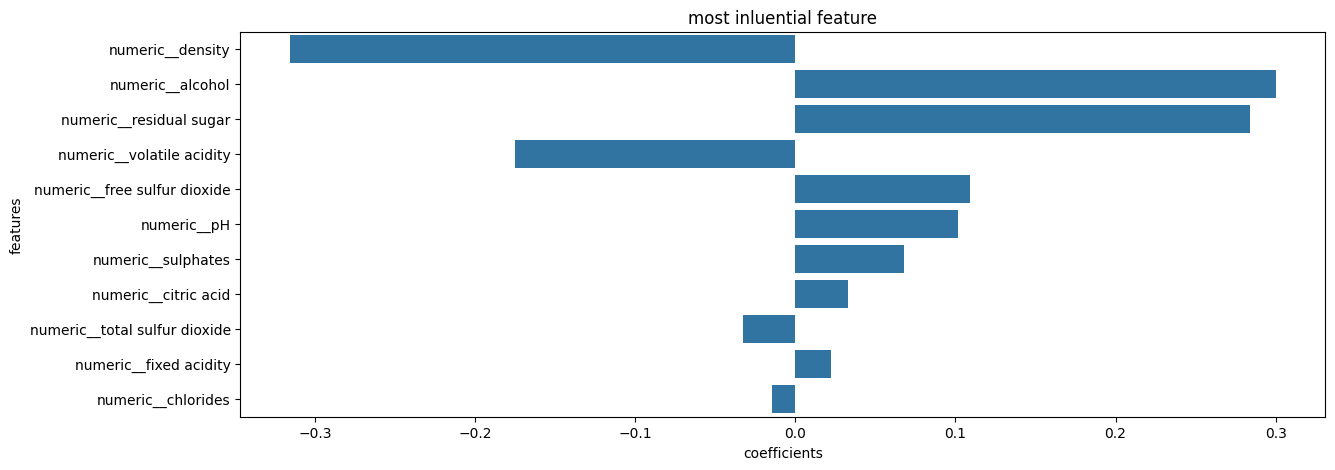

In [120]:
top_coef = coef_df.head(15) 

plt.figure(figsize=(14,5))
sns.barplot(data = top_coef , x='coefficients' , y='features')
plt.title("most inluential feature")
plt.xlabel('coefficients') 
plt.ylabel('features') 
plt.show()

# ALCOHOL AND RESIDUAL SUGAR ARE THE DOMINANT PREDICTOR OF THE QUALITY , FOLLOWED BY FREE SULFUR DIOXIDE , WHILE DENSITY AND COLATILE ACIDITY HAVE LARGE NEGATIVE COEFFICIENTS , INDICATING -VE RELATION WITH QUALITY 

# PLOT OF ACTUAL VS PREDICTED quality

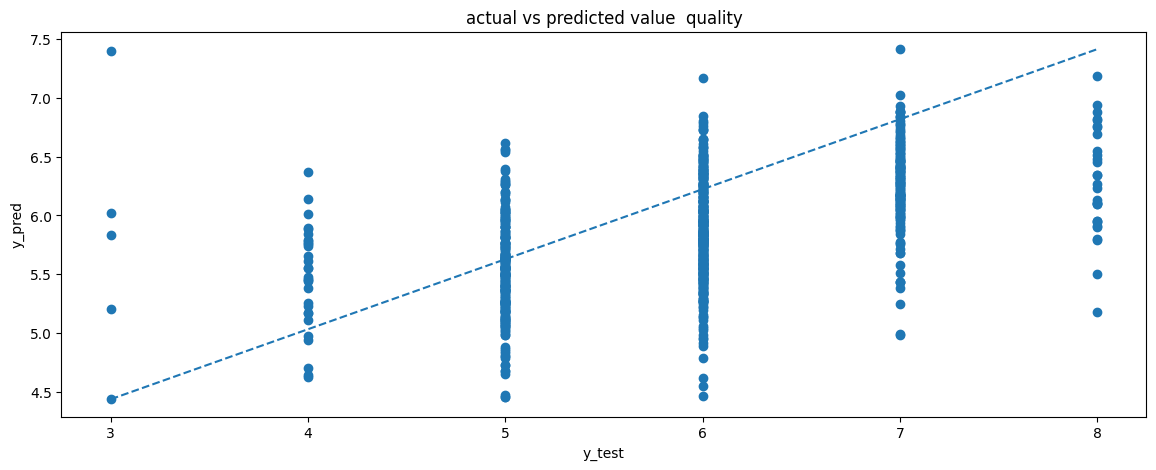

In [123]:
plt.figure(figsize=(14,5))
plt.scatter(y_test , y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title("actual vs predicted value  quality")

# prediction line   
plt.plot([y_test.min() , y_test.max()] ,[ y_pred.min() , y_pred.max() ] , linestyle = '--')
plt.show()

# The plot shows a general increasing trend between actual and predicted wine quality, indicating that the model captures some relationship between the input chemical features and wine quality. However, the predictions are widely scattered around the reference line, particularly for individual quality levels. The model also tends to predict values closer to the middle of the quality range, resulting in overprediction of lower-quality wines and underprediction of higher-quality wines. This indicates that the linear regression model has limited ability to capture the variation in wine quality, which is consistent with the relatively low test R² of 0.2597.

# residual plot 

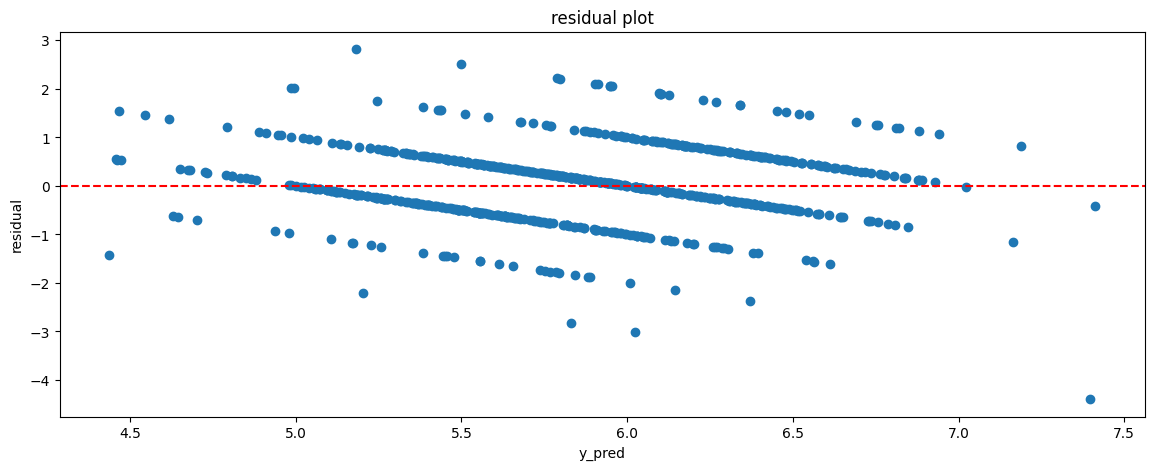

In [124]:
residual = y_test - y_pred 

plt.figure(figsize=(14,5))
plt.scatter(y_pred , residual) 
plt.axhline(y=0 , color='red' , linestyle = '--')
plt.title("residual plot")
plt.xlabel('y_pred')
plt.ylabel('residual')
plt.show()


# The residuals are distributed around zero, indicating that the model does not show a strong systematic overprediction or underprediction. However, several large residuals are present, indicating that the model has difficulty predicting some observations accurately. The visible diagonal bands are largely due to the discrete integer-valued nature of the wine quality target